In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Step1: **Import Necessary Libraries**

In [7]:
import pandas as yo
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, precision_score, precision_recall_curve, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

# Step2: **Load the Dataset**

In [8]:
train_data = yo.read_csv('imdb_top_2000_movies.csv')
test_data = yo.read_csv('imdb_top_2000_movies.csv')
test_data_solution = yo.read_csv('imdb_top_2000_movies.csv')
train_data.head()
test_data.head()
test_data_solution.head()


,Movie Name,Release Year,Duration,IMDB Rating,Metascore,Votes,Genre,Director,Cast,Gross
0,The Godfather,1972,175,9.2,100.0,"2,002,655","Crime, Drama",Francis Ford Coppola,Marlon Brando,$134.97M
1,The Godfather Part II,1974,202,9.0,90.0,"1,358,608","Crime, Drama",Francis Ford Coppola,Al Pacino,$57.30M
2,Ordinary People,1980,124,7.7,86.0,"56,476",Drama,Robert Redford,Donald Sutherland,$54.80M
3,Lawrence of Arabia,1962,218,8.3,100.0,"313,044","Adventure, Biography, Drama",David Lean,Peter O'Toole,$44.82M
4,Straw Dogs,1971,113,7.4,73.0,"64,331","Crime, Drama, Thriller",Sam Peckinpah,Dustin Hoffman,NaN


# Step3: **Preprocess the Data**

*1. Convert text data to numerical features, using **TF-IDF***

TF-IDF stands for Term Frequency-Inverse Document Frequency. It's a technique used to convert text data into numerical features. TF-IDF takes into account:

* Term Frequency (TF): How often a word appears in a document.
* Inverse Document Frequency (IDF): How rare a word is across the entire corpus.

Since the machine won't be able to understand text data, we need to convert them into numerical features.

### Defining column indices

In [9]:
train_title = train_data.iloc[:,1]
train_genre = train_data.iloc[:,2]
train_description = train_data.iloc[:,3]

test_title = test_data.iloc[:,1]
test_description = test_data.iloc[:,2]
# train_title.head(10)

train_text_features = train_title.astype(str) + ' ' + train_description.astype(str)
test_text_features = test_title.astype(str) + ' ' + test_description.astype(str)

### Fit the vectorizer to the text features and transform the data

In [10]:
vectorizer = TfidfVectorizer()
x_train = vectorizer.fit_transform(train_text_features)
# print(x_train)
y_train = train_genre

x_test = vectorizer.transform(test_text_features)

# Step4: **Split the Data into Training and Testing Sets**

We don't need to split the data into training and testing set since it is already done. 

# Step5: **Train a Naive Bayes Classifier**

A probabilistic classification algorithm based on Bayes’ Theorem, which assumes that the features are conditionally independent of each other given the class label.

> Efficient for hight-dimensional data (ex: text classification).

***MultinomialNB***: Multinomial Naive Bayes - Classifier
Implements Multinomial Naive Bayes Algorithm.

In [11]:
# using training data
clf = MultinomialNB()   # object clf created of the Class MultinomialNB() - (in scikit-learn)
clf.fit(x_train, y_train)    # fit method is called/used using clf obj.

MultinomialNB()


* *clf:* An instance which will be used to train the model.
* *fit:* A method that trains the model using the provided data.
* **x_train** is the feature matrix (*independent variables*) for the training data.
* **y_train** is the target vector (*dependent variable*) for the training data.


#### The above code snippet creates a Multinomial Naive Bayes classifier and trains it using the training data (X_train and y_train). The trained model can then be used to make predictions on new, unseen data.

# Step6 : **Evaluate the Model**

In [12]:
test_genre = test_data.iloc[:,2]
y_test = test_genre

In [14]:
# using test data
y_pred = clf.predict(x_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report: ")
print(classification_report(y_test, y_pred, zero_division=0))
print("Precision: ", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.0815
Classification Report: 
              precision    recall  f1-score   support

          50       0.00      0.00      0.00         1
          60       0.00      0.00      0.00         1
          64       0.00      0.00      0.00         1
          68       0.00      0.00      0.00         1
          69       0.00      0.00      0.00         2
          75       0.00      0.00      0.00         2
          76       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         2
          78       0.00      0.00      0.00         5
          79       0.00      0.00      0.00         4
          80       0.00      0.00      0.00         4
          81       0.00      0.00      0.00        14
          82       0.00      0.00      0.00         6
          83       0.00      0.00      0.00        13
          84       0.00      0.00      0.00        15
          85       0.00      0.00      0.00        16
          86       0.00      0.00      

# Step7: Visualize

## Confusion Matrix Heatmap

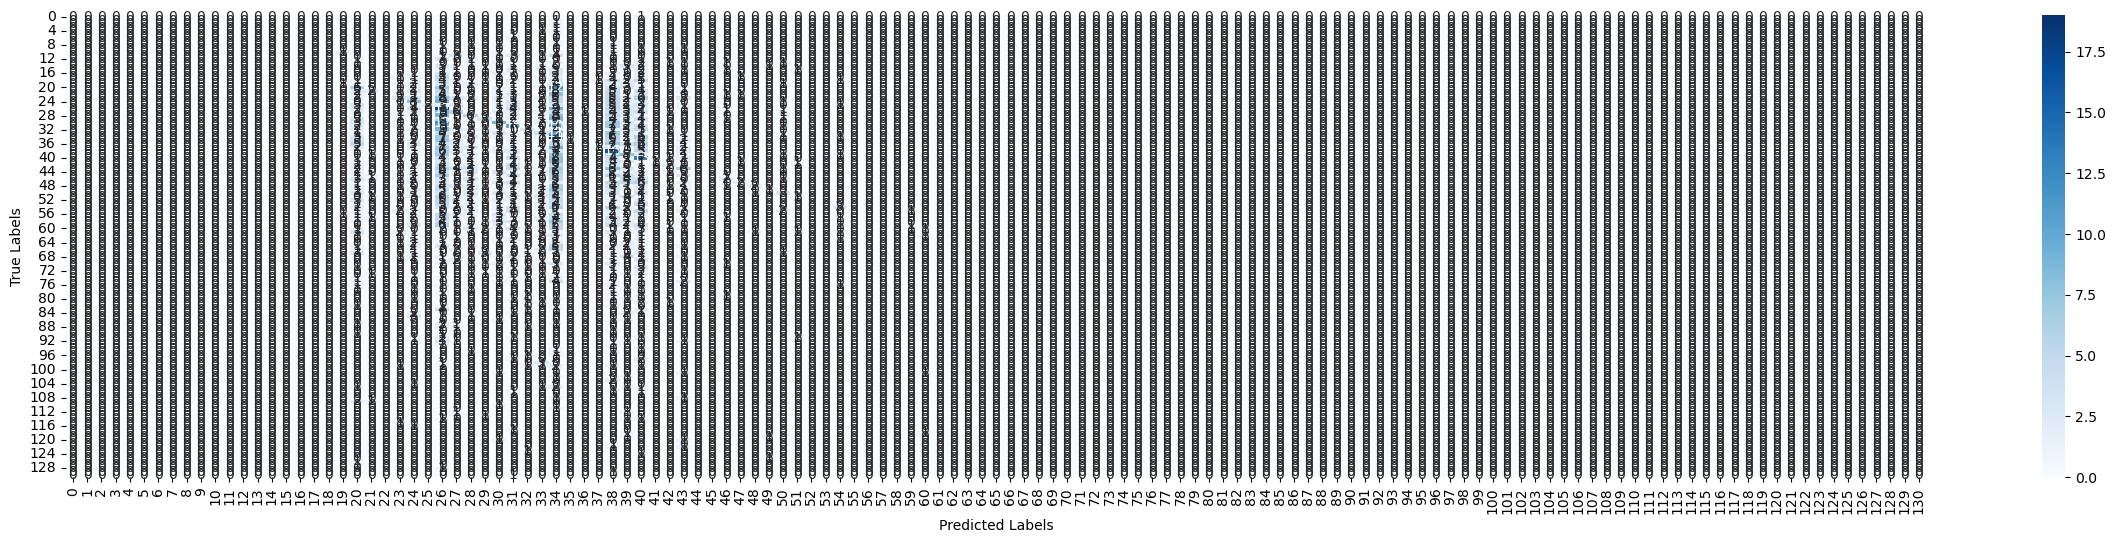

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(30,6))

sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

## Classification Report bar Chart

In [16]:
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Extract the f1-score for each class

In [17]:
f1_scores = [report[x]["f1-score"] for x in report.keys() if x != "accuracy" and x != "macro avg" and x != "weighted avg"]

### Extract the corresponding class labels

In [18]:
class_labels = [x for x in report.keys() if x != "accuracy" and x != "macro avg" and x != "weighted avg"]

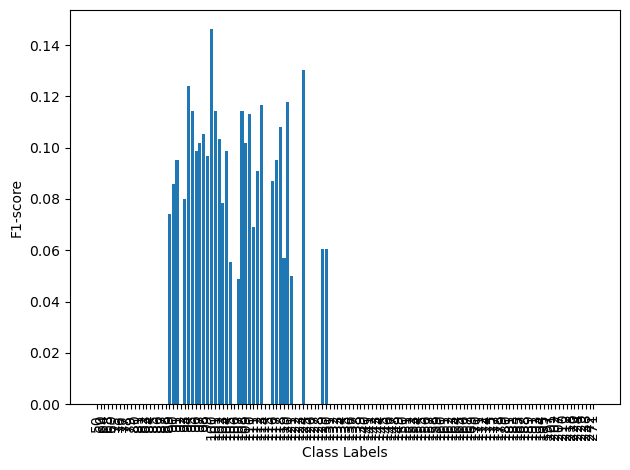

In [32]:
plt.bar(class_labels, f1_scores)
plt.xlabel("Class Labels")
plt.ylabel("F1-score")
plt.xticks(rotation=90)    # rotates the x-axis labels for better readability
plt.tight_layout()    # Adjust the layout to fit the labels
plt.show()

## Precision-Recall Curve

#### Binarize the multiclass labels

In [20]:
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = clf.predict_proba(x_test)

#### Calculate the precision and recall at different thresholds

In [21]:
precision, recall, thresholds = precision_recall_curve(y_test_binarized[:, 0], y_pred_proba[:, 0])

#### Plot the precision-recall curve

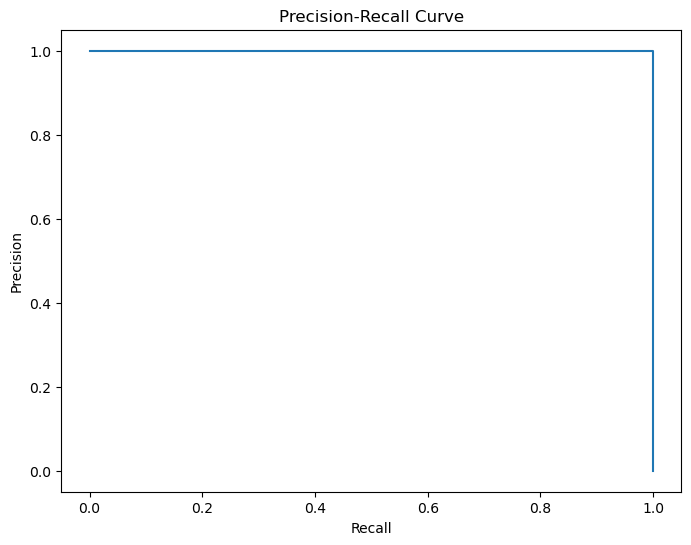

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

#### Count the number of samples in each class

In [23]:
class_counts = y_test.value_counts()

#### Plot a pie chart

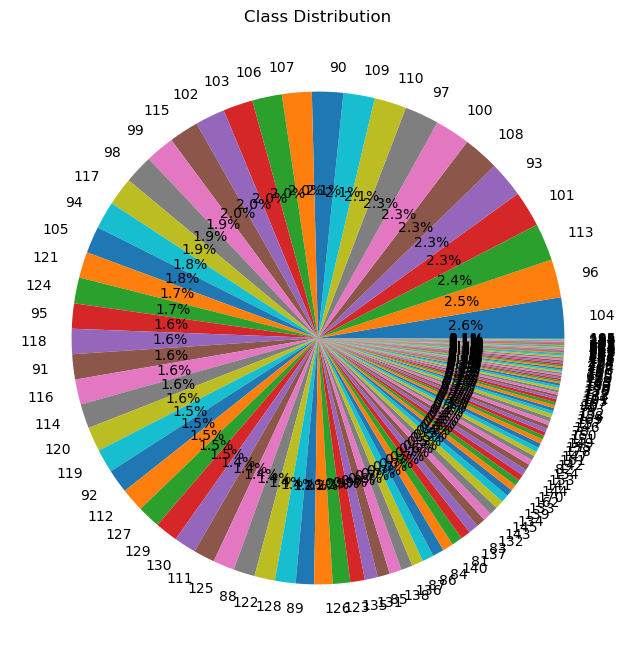

In [24]:
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()

**Zoomin the Graph**

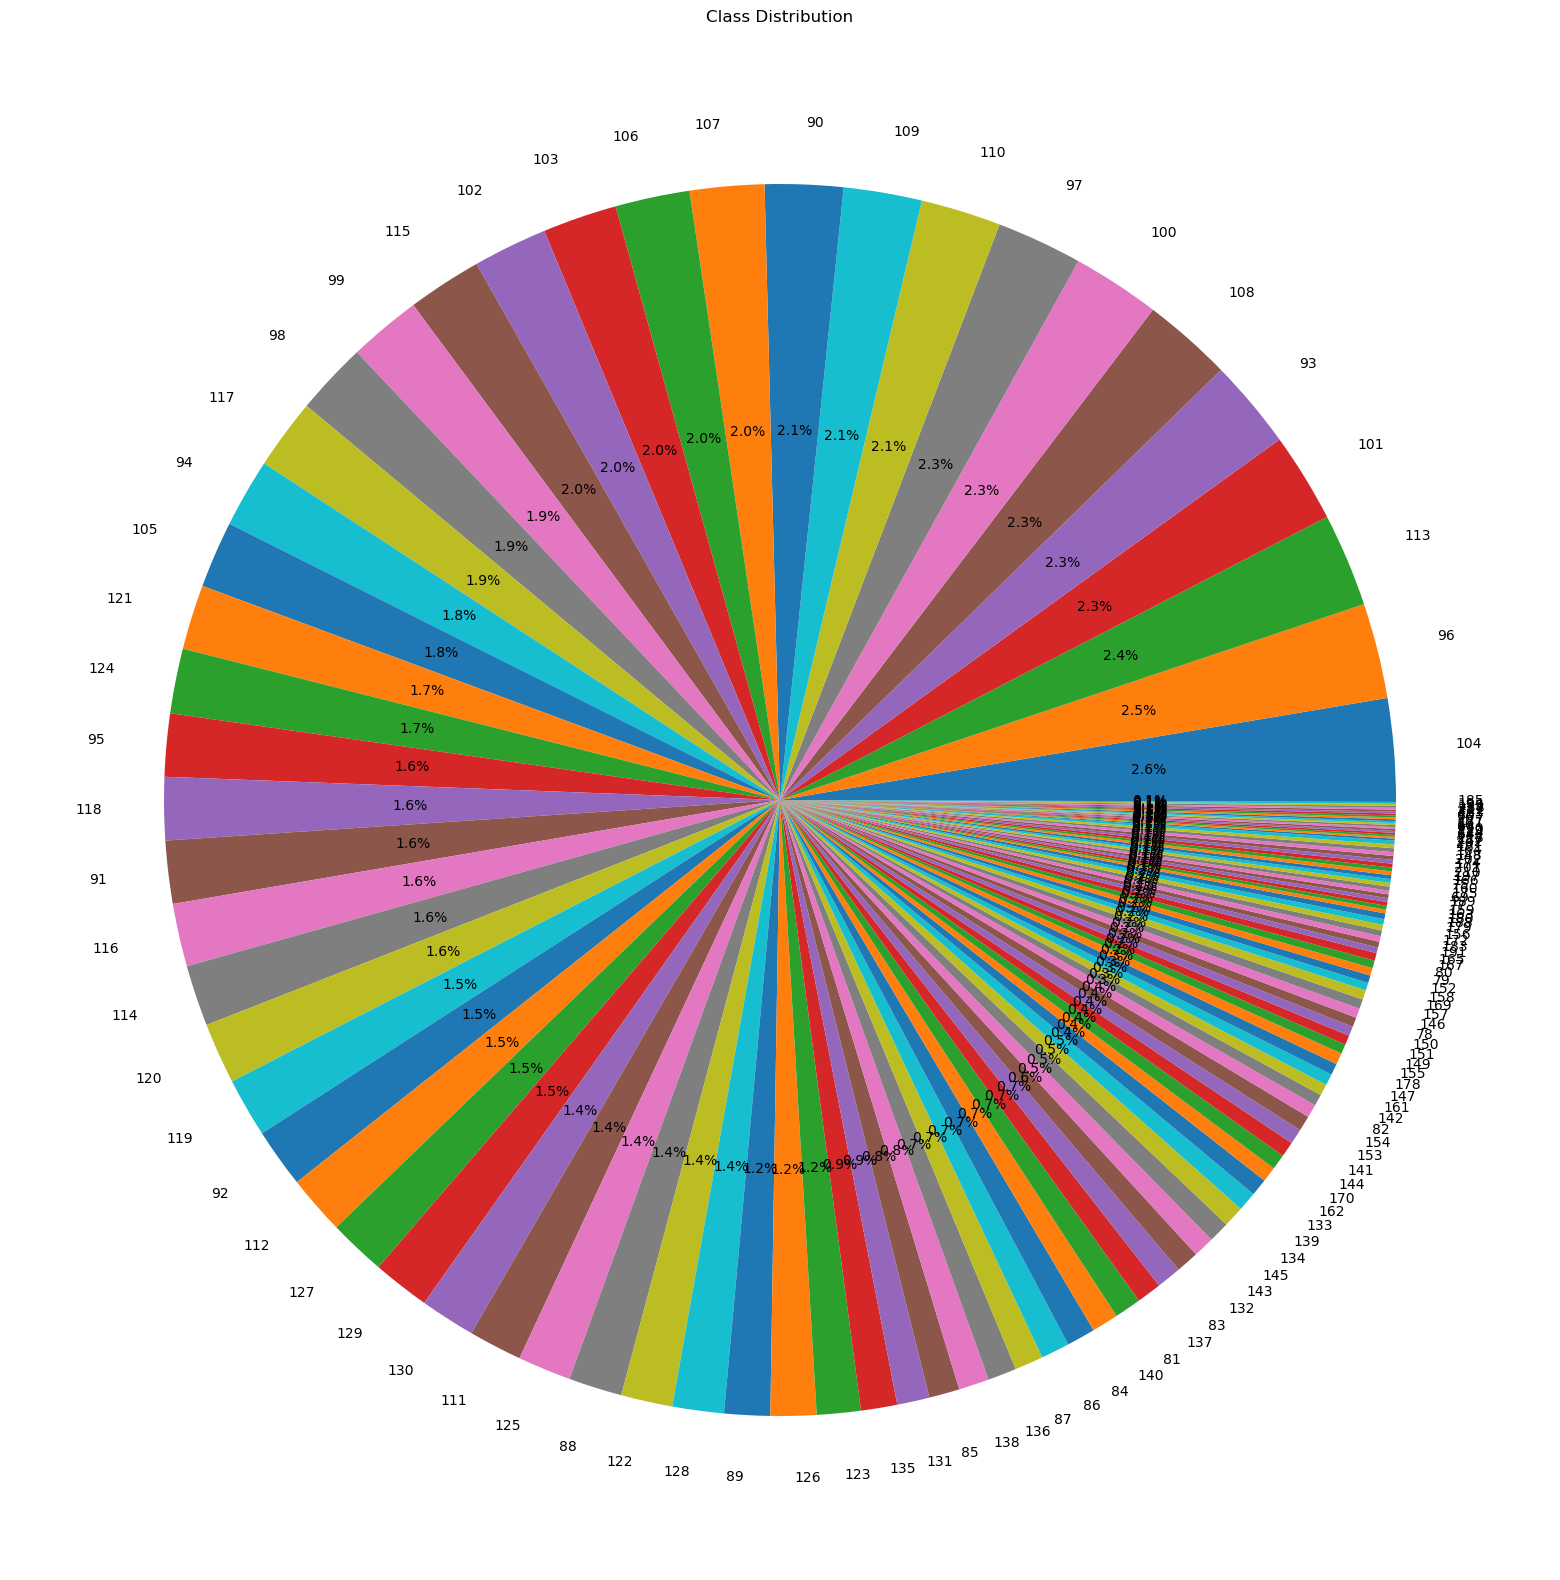

In [25]:
plt.figure(figsize=(20, 20))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()

# Logistic Regression

A statistical method used to analyze a dataset with independent variables to determine a binary outcome.

> Used for Predicting and, Classifying Data.
> Predicts binary outcome (e.g., yes or no).

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [27]:
logreg = LogisticRegression(max_iter = 1000)
logreg.fit(x_train, y_train)
y_pred_logreg = logreg.predict(x_test)

print("Accuracy: ", accuracy_score(y_test, y_pred_logreg))
print("Classification Report: ")
print(classification_report(y_test, y_pred_logreg, zero_division=0))
print("Precision: ", precision_score(y_test, y_pred_logreg, average='macro', zero_division=0))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred_logreg))

Accuracy:  0.0835
Classification Report: 
              precision    recall  f1-score   support

          50       0.00      0.00      0.00         1
          60       0.00      0.00      0.00         1
          64       0.00      0.00      0.00         1
          68       0.00      0.00      0.00         1
          69       0.00      0.00      0.00         2
          75       0.00      0.00      0.00         2
          76       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         2
          78       0.00      0.00      0.00         5
          79       0.00      0.00      0.00         4
          80       0.00      0.00      0.00         4
          81       0.00      0.00      0.00        14
          82       0.00      0.00      0.00         6
          83       0.00      0.00      0.00        13
          84       0.00      0.00      0.00        15
          85       0.00      0.00      0.00        16
          86       0.00      0.00      

# SVM 
##### (Support Vector Machines)

A **Supervised** Machine Learning ALgorithm used for both *Classification* and *Regression* tasks.

> **Note:** SVMs can handle both *linear and nonlinear* data by using different *kernel functions* to transform data into higher-dimensional spaces (where it is easier to find a clear boundary between classes).

In [28]:
from sklearn.svm import LinearSVC

In [29]:
svm = LinearSVC(C=1)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)

print("Accuracy: ", accuracy_score(y_test, y_pred_svm))
print("Classification Report: ")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print("Precision: ", precision_score(y_test, y_pred_svm, average='macro', zero_division=0))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy:  0.0875
Classification Report: 
              precision    recall  f1-score   support

          50       1.00      1.00      1.00         1
          60       1.00      1.00      1.00         1
          64       1.00      1.00      1.00         1
          68       1.00      1.00      1.00         1
          69       0.00      0.00      0.00         2
          75       0.00      0.00      0.00         2
          76       0.00      0.00      0.00         1
          77       0.00      0.00      0.00         2
          78       1.00      0.20      0.33         5
          79       0.00      0.00      0.00         4
          80       0.00      0.00      0.00         4
          81       0.00      0.00      0.00        14
          82       0.00      0.00      0.00         6
          83       1.00      0.08      0.14        13
          84       0.00      0.00      0.00        15
          85       0.00      0.00      0.00        16
          86       0.00      0.00      